In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
data=pd.read_csv('/content/1_Churn_Modelling.csv')

In [ ]:
# Business problem:-To find out whether customers will leave the bank or not.

In [ ]:
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
## missing values check
data.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [ ]:
data.Geography.unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [ ]:
# Converison of categorical data
Geography=pd.get_dummies(data.Geography,drop_first = True)
Gender=pd.get_dummies(data.Gender,drop_first=True)

In [ ]:
Geography

,Germany,Spain
0,False,False
1,False,True
2,False,False
3,False,False
4,False,True
...,...,...
9995,False,False
9996,False,False
9997,False,False
9998,True,False


In [ ]:
Gender

,Male
0,False
1,False
2,False
3,False
4,False
...,...
9995,True
9996,True
9997,False
9998,True


In [ ]:
data=pd.concat([data,Geography,Gender],axis=1)

In [ ]:
data

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Germany,Spain,Male
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0,False,False,True
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,False,False,True
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1,False,False,False
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,True,False,True


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
 14  Germany          10000 non-null  bool   
 15  Spain            10000 non-null  bool   
 16  Male             10000 non-null  bool   
dtypes: bool(3), f

In [ ]:
data.Germany = data.Germany.astype('int64')
data.Spain = data.Spain.astype('int64')
data.Male = data.Male.astype('int64')

In [ ]:
data.head(2)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Germany,Spain,Male
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0,1,0


In [ ]:
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Germany,Spain,Male
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,1,0


In [ ]:
data.drop(['Geography','Gender'],axis=1,inplace=True)

In [ ]:
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Germany,Spain,Male
0,1,15634602,Hargrave,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,2,15647311,Hill,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,3,15619304,Onio,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,4,15701354,Boni,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,5,15737888,Mitchell,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


In [ ]:
data.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited', 'Germany', 'Spain', 'Male'],
      dtype='object')

In [ ]:
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Germany,Spain,Male
0,1,15634602,Hargrave,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,2,15647311,Hill,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,3,15619304,Onio,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,4,15701354,Boni,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,5,15737888,Mitchell,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


In [ ]:
## Creating independent and dependent variable.
X=data.loc[:,['CreditScore', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary','Germany', 'Spain', 'Male']]
y=data.Exited

In [ ]:
y

,Exited
0,1
1,0
2,1
3,0
4,0
...,...
9995,0
9996,0
9997,1
9998,1


In [ ]:
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Male
0,619,42,2,0.00,1,1,1,101348.88,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,0,1


In [ ]:
## Training and testing data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=20)

In [ ]:
X_train.shape

(7500, 11)

In [ ]:
X_test.shape

(2500, 11)

In [ ]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test) # to avoid data leakage


In [ ]:
print(X_train[:,0].mean())
print(X_train[:,0].std())

-2.813749233609997e-16
1.0


In [ ]:
print("{:.10f}".format(X_train[:,0].mean()))

-0.0000000000


<Axes: ylabel='Density'>

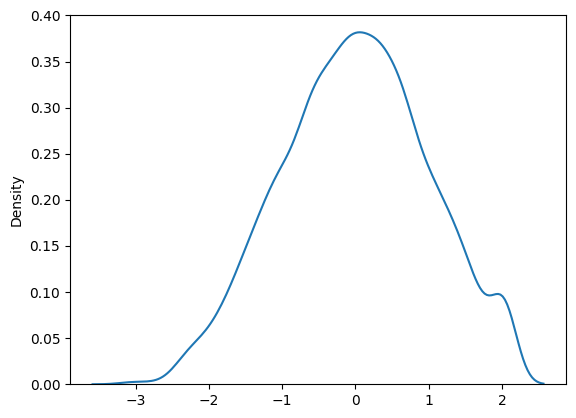

In [ ]:
import seaborn as sns
sns.kdeplot(X_train[:,0])

In [ ]:
## Sequential modelling and functional modelling
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
#from tensorflow.keras.layers import Dropout                     # used to prevent overfitting

In [ ]:
# Defining the model
model=Sequential()

# Adding input layer to first hidden layer
model.add(Dense(units=16,input_dim=11,activation='relu',
                kernel_initializer='he_uniform'))

# Adding first hidden layer to second hidden layer
model.add(Dense(units=20,activation='relu',kernel_initializer='he_uniform'))

# Adding second hidden layer to third hidden layer
model.add(Dense(units=8,activation='relu',kernel_initializer='he_uniform'))

# Adding third hidden layer to output layer
model.add(Dense(units=1,activation='sigmoid',kernel_initializer = 'glorot_uniform'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
weights, bias = model.layers[1].get_weights() #returns the trained parameters of second layer of your Keras model

In [1]:
bias

NameError: name 'bias' is not defined

In [ ]:
weights

array([[ 0.19909745,  0.5096355 ,  0.4026777 , -0.43158472,  0.46509033,
         0.26042426,  0.16251588,  0.11972928, -0.58078617,  0.5589333 ,
        -0.0714891 ,  0.573849  ,  0.19834262,  0.16369104, -0.15033427,
        -0.4605031 ,  0.08593106, -0.5461057 , -0.01244807,  0.3418585 ],
       [-0.38706362,  0.05382562, -0.02811003,  0.32246912,  0.09229261,
         0.4356795 , -0.39439988,  0.17484683,  0.4449504 ,  0.4339531 ,
         0.56099015,  0.52138215, -0.1966931 ,  0.22058278, -0.50608945,
        -0.35272753, -0.504682  ,  0.4062832 ,  0.13204807, -0.16219467],
       [-0.46011752,  0.36361778,  0.41261286, -0.54492307, -0.41006622,
        -0.24853876,  0.22732383,  0.2465415 ,  0.32889855,  0.1779393 ,
         0.04894388,  0.10276455, -0.15889168,  0.21746421, -0.33228624,
         0.17695189, -0.44982257, -0.4283756 ,  0.39926535, -0.02771872],
       [ 0.08438665, -0.60845613, -0.15005833,  0.43807966,  0.29259366,
         0.609587  , -0.25574055,  0.4595595 ,  

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │           340 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 709 (2.77 KB)

 Trainable params: 709 (2.77 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
...
# compile the keras model
model.compile(loss='binary_crossentropy', optimizer='adam',
              metrics=['accuracy'])

In [ ]:
# fit the keras model on the dataset
model_history=model.fit(X_train, y_train, epochs=10,validation_split=0.33, batch_size=10,verbose=1)

Epoch 1/10
503/503 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.7837 - loss: 0.5313 - val_accuracy: 0.8061 - val_loss: 0.4516
Epoch 2/10
503/503 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8030 - loss: 0.4598 - val_accuracy: 0.8162 - val_loss: 0.4324
Epoch 3/10
503/503 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8143 - loss: 0.4245 - val_accuracy: 0.8191 - val_loss: 0.4203
Epoch 4/10
503/503 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8229 - loss: 0.4159 - val_accuracy: 0.8275 - val_loss: 0.4094
Epoch 5/10
503/503 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8008 - loss: 0.4339 - val_accuracy: 0.8364 - val_loss: 0.3995
Epoch 6/10
503/503 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8253 - loss: 0.4043 - val_accuracy: 0.8397 - val_loss: 0.3891
Epoch 7/10
503/503 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8246 - loss: 0.3980 - val_accuracy: 0.8473 - val_loss: 0.3696
Epoch 8/10
503/503 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8355 - loss: 0.3844 - val_accuracy: 

In [ ]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [ ]:
model_history.history['loss'] # gives the training accuracy for all the 50 epochs

[0.5050142407417297,
 0.4560251832008362,
 0.4400694966316223,
 0.42814695835113525,
 0.41753697395324707,
 0.4052887558937073,
 0.39187800884246826,
 0.38118359446525574,
 0.3722412586212158,
 0.3667234778404236]

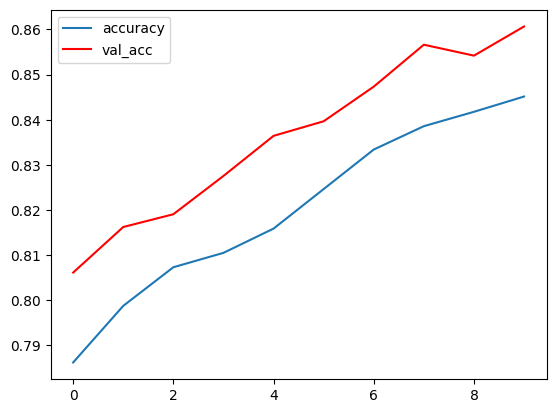

In [ ]:
import matplotlib.pyplot as plt
plt.plot(model_history.history['accuracy'],label='accuracy')
plt.plot(model_history.history['val_accuracy'],color='red',label='val_acc')
plt.legend()


In [ ]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [ ]:
y_test

,Exited
9957,0
1687,0
2116,0
231,0
2780,0
...,...
8514,0
5190,0
6766,1
347,0


In [ ]:

y_pred   #

array([[0.05150775],
       [0.02930406],
       [0.03425532],
       ...,
       [0.23693219],
       [0.739718  ],
       [0.0387405 ]], dtype=float32)

In [ ]:
abc = []
for i in y_pred:
  if i[0] <= 0.5:
      abc.append(0)
  else:
    abc.append(1)
abc = np.array(abc)

In [ ]:
abc

array([0, 0, 0, ..., 0, 1, 0])

In [ ]:
## < 0.5 = 0
## >= 0.5 = 1

y_prediction = np.array([1 if i >= 0.5 else 0 for i in y_pred.reshape(2500,)])

In [ ]:
accuracy_score(y_test,y_prediction)

0.858

In [ ]:
model.evaluate(X_test,y_test)

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8723 - loss: 0.3375


[0.35715728998184204, 0.8579999804496765]

In [ ]:
...
# evaluate the keras model
accuracy = model.evaluate(X_test, y_test)
accuracy

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8723 - loss: 0.3375


[0.35715728998184204, 0.8579999804496765]

In [ ]:
# list all data in history
print(model_history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [ ]:
model_history.history

{'accuracy': [0.7862260937690735,
  0.7987658977508545,
  0.8073248267173767,
  0.8105095624923706,
  0.8158837556838989,
  0.8246417045593262,
  0.8333996534347534,
  0.8385748267173767,
  0.8417595624923706,
  0.8451433181762695],
 'loss': [0.5050142407417297,
  0.4560251832008362,
  0.4400694966316223,
  0.42814695835113525,
  0.41753697395324707,
  0.4052887558937073,
  0.39187800884246826,
  0.38118359446525574,
  0.3722412586212158,
  0.3667234778404236],
 'val_accuracy': [0.8061389327049255,
  0.8162358403205872,
  0.8190630078315735,
  0.8275444507598877,
  0.8364297151565552,
  0.8396607637405396,
  0.8473343849182129,
  0.8566235899925232,
  0.8542003035545349,
  0.8606623411178589],
 'val_loss': [0.45161011815071106,
  0.43236663937568665,
  0.42032238841056824,
  0.40937289595603943,
  0.3995051085948944,
  0.38908088207244873,
  0.3696006238460541,
  0.35688531398773193,
  0.35158461332321167,
  0.34264761209487915]}

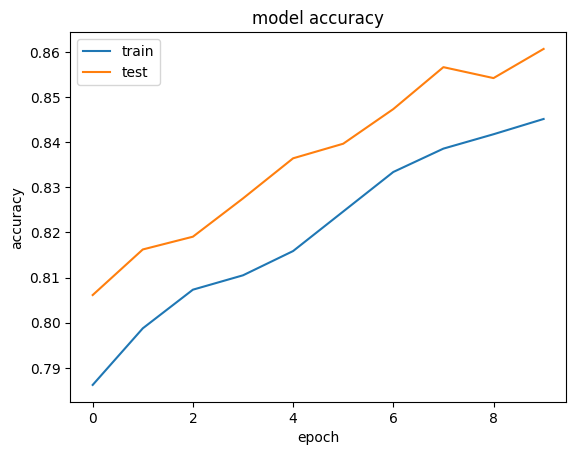

In [ ]:
# summarize history for accuracy
import matplotlib.pyplot as plt
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'])
plt.show()

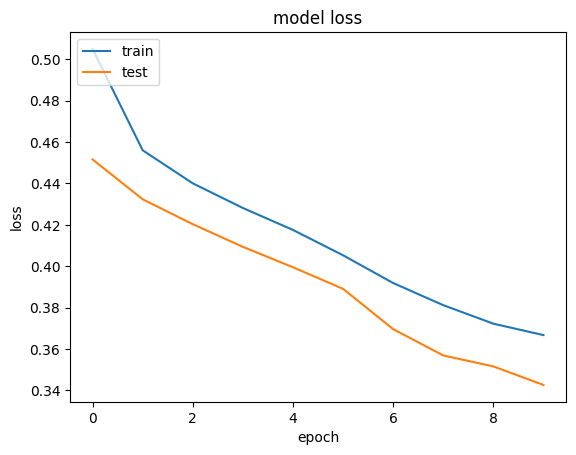

In [ ]:
# summarize history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [ ]:
#Making the predictions and evaluating the model

# Predicting the Test set results
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[1959,   63],
       [ 292,  186]])

In [ ]:
# Calculate the Accuracy
from sklearn.metrics import accuracy_score
score=accuracy_score(y_pred,y_test)
score